In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.svm import SVC

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import re


nltk.download("punkt_tab")
nltk.download("punkt")
nltk.download("stopwords")

import joblib
import streamlit as st


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\TAHIR\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\TAHIR\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TAHIR\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Loading Dataset

In [2]:
df = pd.read_csv(r"d:\Downloads\Reviews.csv\Reviews.csv")
df = df.sample(n=15000, random_state=42).reset_index(drop=True)
print("Dataset shape:", df.shape)
display(df.head())
 

Dataset shape: (15000, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,165257,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",0,0,5,1268179200,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...
1,231466,B0000BXJIS,A3U62RE5XZDP0G,Marty,0,0,5,1298937600,great kitty treats,My cat loves these treats. If ever I can't fin...
2,427828,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,0,2,3,1224028800,COFFEE TASTE,A little less than I expected. It tends to ha...
3,433955,B006BXV14E,A3PWPNZVMNX3PA,rareoopdvds,0,1,2,1335312000,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin..."
4,70261,B007I7Z3Z0,A1XNZ7PCE45KK7,Og8ys1,0,2,5,1334707200,Great Taste . . .,and I want to congratulate the graphic artist ...


### Cleaning Data

In [3]:
#Checking for missing values
print("Missing Values:" )
print(df.isnull().sum())

#Finding records that contain missing values
#print(df[df.isna().any(axis=1)])

# removing missing values
df.dropna(inplace = True)

# verify data is clean
print("\n Missing Values Left:")
print(df.isna().sum().sum())



Missing Values:
Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   1
Text                      0
dtype: int64

 Missing Values Left:
0


In [4]:
# Checking for duplicates
print(df.duplicated().sum())

0


In [5]:
# creating new feature
df["Review"] = df["Summary"] + " " + df["Text"]

In [6]:
# handling html tags
def remove_html(review):
    return re.sub(r"<.*?>", "", review)

df["Review"] = df["Review"].apply(remove_html)

# handling URLs
def remove_urls(review):
    return re.sub(r"http\S+", "", review)

df["Review"] = df["Review"].apply(remove_urls)

# handling emojis and symbols
def remove_symbols(review):
    return re.sub(r"[^\w\s]", "", review)

df["Review"] = df["Review"].apply(remove_symbols)



### Labeling Data

In [7]:
def label_sentiment(Score):
    if Score <= 2:
        return "Negative"
    elif Score == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Score"].apply(label_sentiment)

print(df[["Score", "Sentiment"]].head(10))

df["Sentiment"].value_counts()

   Score Sentiment
0      5  Positive
1      5  Positive
2      3   Neutral
3      2  Negative
4      5  Positive
5      4  Positive
6      5  Positive
7      5  Positive
8      4  Positive
9      5  Positive


Sentiment
Positive    11719
Negative     2148
Neutral      1132
Name: count, dtype: int64

### Visualizing the Class Distribution

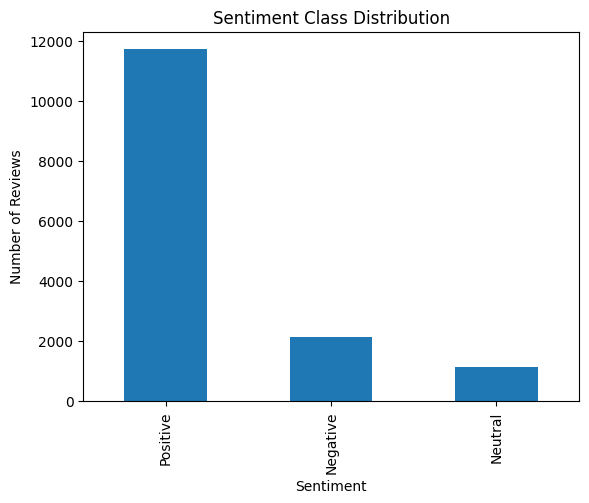

In [8]:
df["Sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

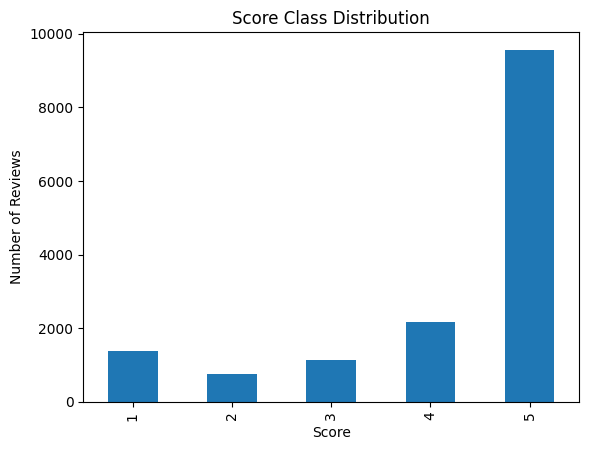

In [9]:
df["Score"].value_counts().sort_index().plot(kind="bar")
plt.title("Score Class Distribution")
plt.xlabel("Score")
plt.ylabel("Number of Reviews")
plt.show()

### Text Preprocessing

In [10]:
stop_words = set(stopwords.words("english"))
# Keep important negation words
stop_words.discard("not")
stop_words.discard("no")
stop_words.discard("nor")
stop_words.discard("never")


def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token not in string.punctuation]
    tokens = [token for token in tokens if token not in stop_words]
    return " ".join(tokens)
df["Cleaned_Review"] = df["Review"].apply(preprocess)

print(df["Cleaned_Review"])


0        crunchy good glutenfree sandwich cookies tried...
1        great kitty treats cat loves treats ever cant ...
2        coffee taste little less expected tends muddy ...
3        miniwheats big first frosted miniwheats origin...
4        great taste want congratulate graphic artist p...
                               ...                        
14995    tullys decaf french roast kcups love bold rich...
14996    little taste home western kentucky great find ...
14997    good tea impressed tazos china green tips tea ...
14998    blueberries best though not lowcalorie strawbe...
14999    worth price adopted 6 monthold dalmationpit re...
Name: Cleaned_Review, Length: 14999, dtype: str


In [11]:
vectorizer = TfidfVectorizer(ngram_range=(1,2))
tfidf_matrix = vectorizer.fit_transform(df["Cleaned_Review"])
feature_names = vectorizer.get_feature_names_out()
word_counts = np.asarray(tfidf_matrix.sum(axis=0)).ravel()

In [12]:
word_counts = np.asarray(tfidf_matrix.sum(axis=0)).ravel()
feature_names = vectorizer.get_feature_names_out()

top_indices = word_counts.argsort()[-20:][::-1]

df_tfidf = pd.DataFrame(
    tfidf_matrix[:, top_indices].toarray(),
    columns=feature_names[top_indices]
)

### Data Visualization

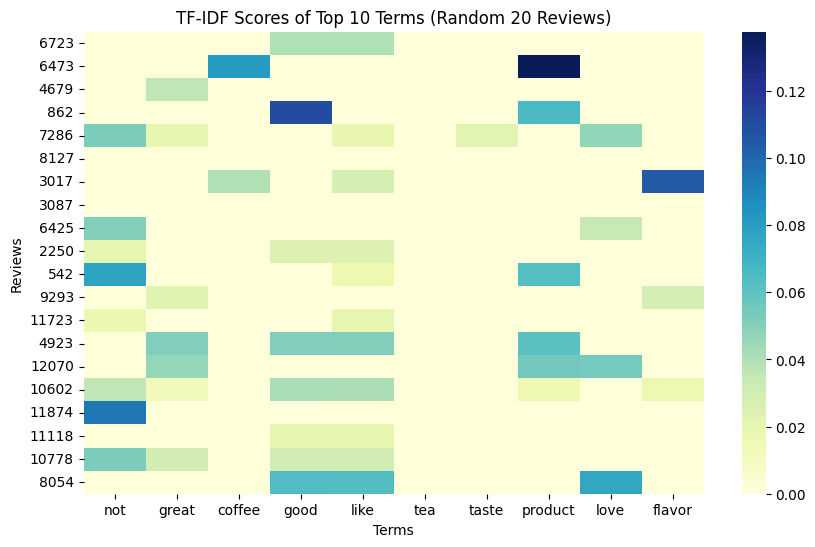

In [13]:
# Select the 10 terms with the highest total TF-IDF scores
top_terms = df_tfidf.sum().sort_values(ascending=False).head(10).index

# Create a DataFrame containing only those 10 terms
df_top10 = df_tfidf[top_terms]

sample_reviews = df_top10.sample(20, random_state=42)

plt.figure(figsize=(10,6))
sns.heatmap(sample_reviews, cmap="YlGnBu")

plt.title("TF-IDF Scores of Top 10 Terms (Random 20 Reviews)")
plt.xlabel("Terms")
plt.ylabel("Reviews")

plt.show()

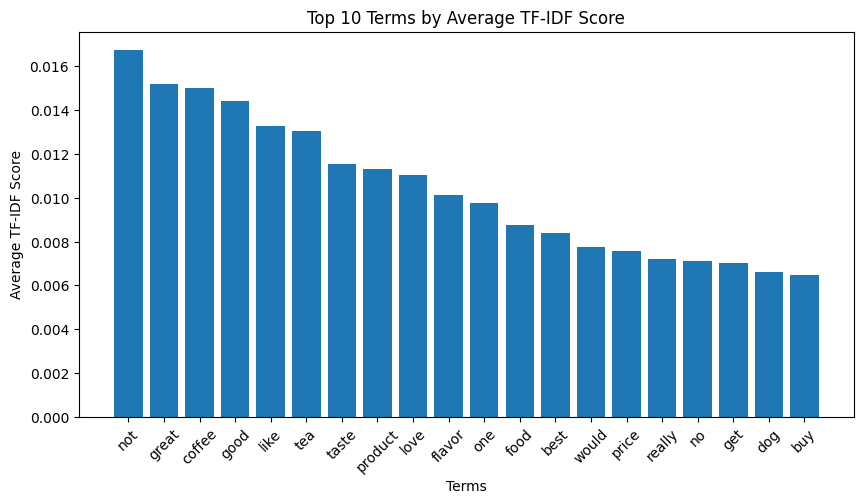

In [14]:
avg_tfidf = df_tfidf.mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,5))
plt.bar(avg_tfidf.index, avg_tfidf.values)

plt.title("Top 10 Terms by Average TF-IDF Score")
plt.xlabel("Terms")
plt.ylabel("Average TF-IDF Score")
plt.xticks(rotation=45)

plt.show()

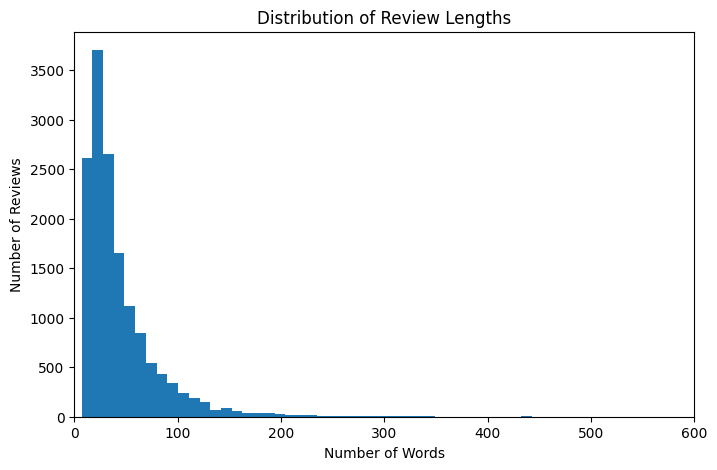

In [15]:
def count_words(review):
    return len(review.split())

df["Review_Length"] = df["Cleaned_Review"].apply(count_words)

plt.figure(figsize=(8,5))
plt.hist(df["Review_Length"], bins=100)
plt.xlim(0, 600)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()

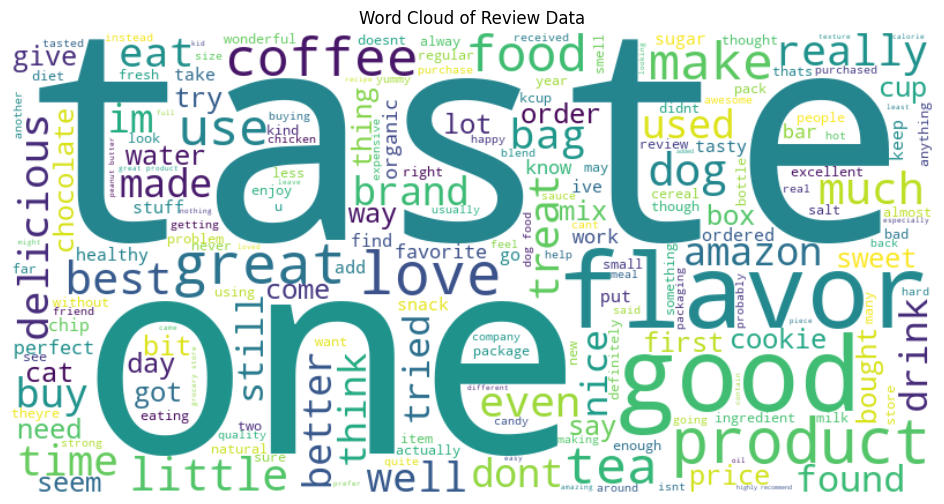

In [16]:
text = " ".join(df["Cleaned_Review"])
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title("Word Cloud of Review Data")

plt.show()

### Training Data

In [17]:
# Features
X = tfidf_matrix

# Labels
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

 Logistic Regression Model

In [18]:
# Instantiate the model
logreg = LogisticRegression(class_weight='balanced')

# Fit the model
logreg.fit(X_train, y_train)

# make predictions
y_pred_logreg = logreg.predict(X_test)

print("Accuracy of Logistic Regression Model:", accuracy_score(y_test, y_pred_logreg))



Accuracy of Logistic Regression Model: 0.8513333333333334


Multinomial Naive Bayes Model

In [19]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print("Accuracy of Multinomial Naive Bayes Model:", accuracy_score(y_test, y_pred_nb))


Accuracy of Multinomial Naive Bayes Model: 0.7813333333333333


Linear SVM Model

In [20]:
svm = LinearSVC(class_weight= "balanced")
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("Accuracy of SVM model:", accuracy_score(y_test, y_pred_svm))



Accuracy of SVM model: 0.866


### Comparing the Models

In [21]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Linear SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.851333
1          Naive Bayes  0.781333
2           Linear SVM  0.866000


Linear SVM has higher accuracy score. 

### Evaluating SVM Model

In [22]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))


Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.63      0.70       430
     Neutral       0.54      0.12      0.19       226
    Positive       0.88      0.98      0.93      2344

    accuracy                           0.87      3000
   macro avg       0.74      0.58      0.61      3000
weighted avg       0.84      0.87      0.84      3000


Confusion Matrix:
[[ 271   14  145]
 [  37   26  163]
 [  35    8 2301]]


In [23]:
svm_classifier = LinearSVC()
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
cross_val_results = cross_val_score(svm_classifier, X, y, cv=kf)
print("Cross-Validation Results (Accuracy):")
for i, result in enumerate(cross_val_results, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")
    
print(f'Mean Accuracy: {cross_val_results.mean()* 100:.2f}%')

Cross-Validation Results (Accuracy):
  Fold 1: 86.93%
  Fold 2: 85.90%
  Fold 3: 86.00%
  Fold 4: 85.27%
  Fold 5: 86.26%
Mean Accuracy: 86.07%


In [24]:
# filename = 'svm_sentiment_analysis_model.pkl'
joblib.dump(svm, 'svm_sentiment_analysis_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [25]:
load_model = joblib.load('svm_sentiment_analysis_model.pkl')

In [26]:
print(type(load_model))

<class 'sklearn.svm._classes.LinearSVC'>
